# 02 — Baseline: Silero VAD + silence threshold

**Goal:** Build the simplest modern baseline — Silero VAD detects speech and silence, then a silence-threshold rule decides when the user is "done".

**Why ONNX instead of `torch.hub.load`:** the pip-installed `silero-vad` package imports `torchaudio`, which has an ABI mismatch with our conda torch. Using the ONNX model directly via `onnxruntime` bypasses that — and is actually closer to how production systems run VAD anyway (faster, lighter, no torch dependency at inference).

In [1]:
import os
import json
import numpy as np
import onnxruntime as ort
import librosa
import librosa.display
import matplotlib.pyplot as plt

MODEL_PATH = '../models/silero_vad.onnx'
DATA_DIR = '../data'

print('onnxruntime:', ort.__version__)
print('librosa    :', librosa.__version__)

onnxruntime: 1.25.1
librosa    : 0.11.0


## SileroVAD wrapper

Silero VAD takes 32ms chunks (512 samples at 16kHz) and outputs a per-chunk probability of speech. The model is stateful — we pass the LSTM state forward across chunks so the model sees temporal context.

This is a thin wrapper that hides the state plumbing and exposes one method: `get_speech_probabilities(audio)` — returns one probability per chunk.

In [2]:
class SileroVAD:
    SAMPLE_RATE      = 16000
    CHUNK_SAMPLES    = 512   # 32ms at 16kHz — fixed by the model
    CONTEXT_SAMPLES  = 64    # v5 needs left-context from previous chunk

    def __init__(self, model_path):
        self.session = ort.InferenceSession(model_path)

    def get_speech_probabilities(self, audio):
        """Run VAD on full audio. Returns list of (timestamp_seconds, prob_speech).

        v5 model needs the last 64 samples of the previous chunk prepended to
        each new chunk. Without this context the model output stays near zero.
        """
        state = np.zeros((2, 1, 128), dtype=np.float32)
        context = np.zeros(self.CONTEXT_SAMPLES, dtype=np.float32)
        sr = np.array(self.SAMPLE_RATE, dtype=np.int64)
        probs = []
        for start in range(0, len(audio), self.CHUNK_SAMPLES):
            chunk = audio[start:start + self.CHUNK_SAMPLES]
            if len(chunk) < self.CHUNK_SAMPLES:
                chunk = np.pad(chunk, (0, self.CHUNK_SAMPLES - len(chunk)))
            x = np.concatenate([context, chunk]).reshape(1, -1).astype(np.float32)
            prob, state = self.session.run(None, {'input': x, 'state': state, 'sr': sr})
            context = chunk[-self.CONTEXT_SAMPLES:].astype(np.float32)
            t = start / self.SAMPLE_RATE
            probs.append((t, float(prob[0][0])))
        return probs

vad = SileroVAD(MODEL_PATH)
print('SileroVAD loaded.')

SileroVAD loaded.


## Load audio

Let's load one of our recorded clips from `../data/` to test the pipeline. If the folder is empty, the code falls back to librosa's built-in trumpet sample so the notebook remains runnable.

In [3]:
CLIP_PATH = os.path.join(DATA_DIR, 'clip-01.wav')

if os.path.exists(CLIP_PATH):
    y, sr = librosa.load(CLIP_PATH, sr=SileroVAD.SAMPLE_RATE)
    print(f'Loaded {CLIP_PATH}')
else:
    y, sr = librosa.load(librosa.ex('trumpet'), sr=SileroVAD.SAMPLE_RATE)
    print('No clip-01.wav yet — using librosa trumpet sample as placeholder')

print(f'Duration: {len(y)/sr:.2f}s  |  Samples: {len(y)}  |  SR: {sr}Hz')

Loaded ../data/clip-01.wav
Duration: 7.68s  |  Samples: 122880  |  SR: 16000Hz


## Run VAD and find speech segments

In [4]:
VAD_THRESHOLD = 0.5   # standard Silero threshold for speech vs not-speech

probs = vad.get_speech_probabilities(y)
times = np.array([t for t, _ in probs])
speech_probs = np.array([p for _, p in probs])
is_speech = speech_probs > VAD_THRESHOLD

def segments_from_mask(times, mask, chunk_duration):
    """Convert per-chunk speech mask into (start, end) speech segments."""
    segments = []
    in_speech = False
    seg_start = None
    for t, s in zip(times, mask):
        if s and not in_speech:
            seg_start = t
            in_speech = True
        elif not s and in_speech:
            segments.append((seg_start, t))
            in_speech = False
    if in_speech:
        segments.append((seg_start, times[-1] + chunk_duration))
    return segments

chunk_dur = SileroVAD.CHUNK_SAMPLES / SileroVAD.SAMPLE_RATE
speech_segments = segments_from_mask(times, is_speech, chunk_dur)

print(f'Found {len(speech_segments)} speech segments:')
for s, e in speech_segments:
    print(f'  {s:6.2f}s -> {e:6.2f}s  (duration {e-s:.2f}s)')

Found 1 speech segments:
    2.40s ->   5.70s  (duration 3.30s)


## The baseline rule: `predict_done_baseline`

Here's the baseline rule: Walk through the silence gaps between speech segments. The first time we see a silence gap longer than `threshold_ms`, we declare the user "done" at the start of that gap.

This is a very simple approach with no understanding of *what* was said. We expect it to frequently cut users off mid-sentence during natural pauses.

In [5]:
def predict_done_baseline(speech_segments, total_duration, threshold_ms=500):
    """Return timestamp where baseline says 'user is done', or None if it never fires."""
    threshold_s = threshold_ms / 1000.0
    if not speech_segments:
        return None

    for i in range(len(speech_segments) - 1):
        gap_start = speech_segments[i][1]
        gap_end   = speech_segments[i + 1][0]
        if gap_end - gap_start >= threshold_s:
            return gap_start

    trailing = total_duration - speech_segments[-1][1]
    if trailing >= threshold_s:
        return speech_segments[-1][1]

    return None

duration = len(y) / sr
predicted_done = predict_done_baseline(speech_segments, duration, threshold_ms=500)
if predicted_done is not None:
    print(f'Baseline says user done at: {predicted_done:.2f}s')
else:
    print('Baseline never fired (no silence gap >= threshold)')

Baseline says user done at: 5.70s


## Visualise — waveform + VAD segments + predicted done timestamp

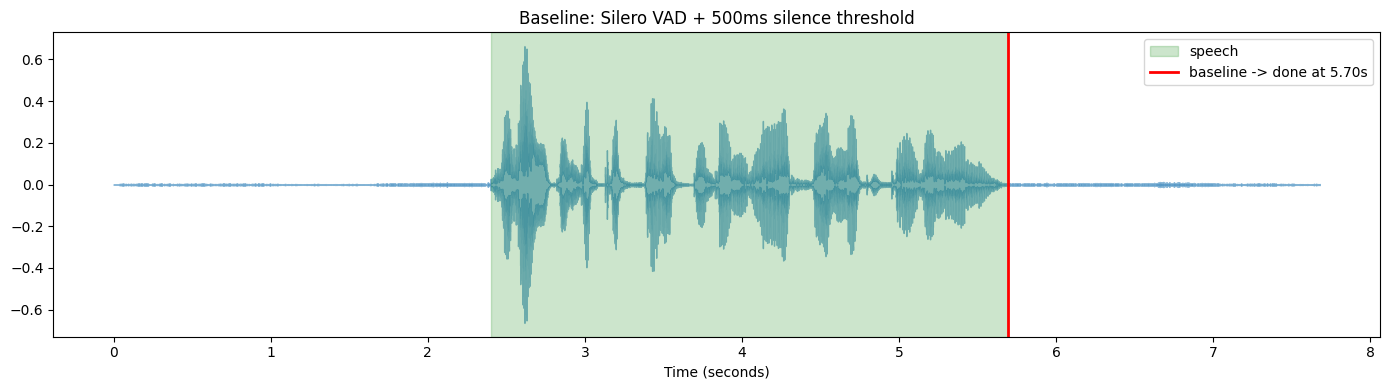

In [6]:
fig, ax = plt.subplots(figsize=(14, 4))
librosa.display.waveshow(y, sr=sr, alpha=0.5, ax=ax)

for i, (s, e) in enumerate(speech_segments):
    ax.axvspan(s, e, color='green', alpha=0.2, label='speech' if i == 0 else None)

if predicted_done is not None:
    ax.axvline(predicted_done, color='red', linewidth=2,
               label=f'baseline -> done at {predicted_done:.2f}s')

ax.set_title('Baseline: Silero VAD + 500ms silence threshold')
ax.set_xlabel('Time (seconds)')
ax.legend(loc='upper right')
plt.tight_layout()
plt.show()

## Run on all clips

Iterate over all clips in `data/labels.json` and produce a per-clip results table.

**Schema:** `labels.json` is keyed by filename. Each entry has `text`, `duration_s`, `user_started_at_s`, `user_finished_at_s`, `overall_class` (`finished` / `unfinished` / `wait`), and a `pauses` array. The `_meta` key is metadata and is skipped.

**Note on the `wait` class:** This baseline cannot distinguish `wait` from `finished` — both look like silence acoustically. The smart approach (notebook 03) is what handles this. We'll just mark the `wait` clips in the table so the gap is visible.

If `data/` has no clips, this cell simply skips.

In [7]:
labels_path = os.path.join(DATA_DIR, 'labels.json')

if not os.path.exists(labels_path):
    print('No labels.json yet.')
else:
    with open(labels_path) as f:
        labels = json.load(f)

    rows = []
    for filename, clip in labels.items():
        if filename.startswith('_'):  # skip _meta
            continue
        clip_path = os.path.join(DATA_DIR, filename)
        if not os.path.exists(clip_path):
            print(f'  skip {filename} (file missing)')
            continue

        y_clip, _ = librosa.load(clip_path, sr=SileroVAD.SAMPLE_RATE)
        cprobs = vad.get_speech_probabilities(y_clip)
        ctimes = np.array([t for t, _ in cprobs])
        cmask = np.array([p > VAD_THRESHOLD for _, p in cprobs])
        csegs = segments_from_mask(ctimes, cmask, chunk_dur)
        pred = predict_done_baseline(csegs, len(y_clip)/SileroVAD.SAMPLE_RATE, threshold_ms=500)

        gt = clip.get('user_finished_at_s')
        cls = clip.get('overall_class', '?')
        delta = (pred - gt) if (pred is not None and gt is not None) else None

        # Verdict logic (baseline can only judge timing, not class):
        # - cut    : predicted done before ground truth (cut user off mid-sentence)
        # - late   : predicted done significantly after ground truth (slow response)
        # - ok     : within 0.5s of ground truth
        # - none   : baseline never fired
        # - wait!  : flagged as wait-class (baseline cannot detect this)
        if cls == 'wait':
            verdict = 'wait! (baseline blind)'
        elif pred is None:
            verdict = 'none'
        elif delta is None:
            verdict = '?'
        elif delta < -0.3:
            verdict = 'cut'
        elif delta > 0.5:
            verdict = 'late'
        else:
            verdict = 'ok'

        rows.append({
            'clip': filename,
            'class': cls,
            'gt': gt,
            'pred': pred,
            'delta': delta,
            'verdict': verdict,
            'text': clip.get('text', ''),
        })

    # Print table
    print(f'{"clip":<14}{"class":<11}{"gt":>6}{"pred":>7}{"delta":>7}  {"verdict":<24} text')
    print('-' * 110)
    for r in rows:
        gt = f'{r["gt"]:.2f}' if r['gt'] is not None else '--'
        pr = f'{r["pred"]:.2f}' if r['pred'] is not None else '--'
        dl = f'{r["delta"]:+.2f}' if r['delta'] is not None else '--'
        print(f'{r["clip"]:<14}{r["class"]:<11}{gt:>6}{pr:>7}{dl:>7}  {r["verdict"]:<24} {r["text"][:55]}')

    # Quick aggregate
    print()
    from collections import Counter
    counts = Counter(r['verdict'] for r in rows)
    print('Verdict counts:', dict(counts))

clip          class          gt   pred  delta  verdict                  text
--------------------------------------------------------------------------------------------------------------
clip-01.wav   finished     5.80   5.70  -0.10  ok                       I want to book a flight to Bangalore for next Tuesday m
clip-02.wav   finished     5.90   5.70  -0.20  ok                       I want to book a flight to ...um.. Bangalore for next T
clip-03.wav   finished     4.90   4.80  -0.10  ok                       Hmm I think ... I. aaa. want a window seat please.
clip-04.wav   finished     1.80   1.54  -0.26  ok                       Yes.
clip-05.wav   finished     2.20   2.08  -0.12  ok                       No, that's not right.
clip-06.wav   finished     3.80   3.68  -0.12  ok                       What was the price for the morning flight you mentioned
clip-07.wav   finished     5.90   1.89  -4.01  cut                      Cancel my booking ... actually wait ... change it to ev
clip-0